# MountainCar Discretization

This notebook builds a finite abstract MDP for `MountainCar-v0`.


In [63]:
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import itertools
import imageio

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")
DATASET_PATH = PROJECT_ROOT / "datasets" / "mountaincar.csv"

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fogas_torch import LinearMDP, PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Using device: cuda


## Discretization design

MountainCar observations are `(position, velocity)`.

State grid:
- `position`: 36 bins on `[-1.2, 0.6]`
- `velocity`: 28 bins on `[-0.07, 0.07]`

This gives `36 * 28 = 1008` non-terminal abstract states.

Action space:
- `0`: push left
- `1`: no push
- `2`: push right

The environment already has an exact **discrete** action space, so unlike the continuous version there is no action discretization step.

We add one absorbing abstract state:
- `GOAL_STATE_ID`: successful termination (`position >= 0.5` and `velocity >= goal_velocity`)

Total abstract states: `1009`.

As with the continuous notebook, we do not infer `P` and `r` from data. Gymnasium already gives the exact transition and reward equations, so we build the abstract model directly from them.

We also do **not** add a separate time-limit state. The `200`-step truncation is a wrapper-level constraint that depends on elapsed time, not only on the observation, so it is recorded in the offline dataset but excluded from the Markov abstraction itself.


In [64]:
ENV_ID = "MountainCar-v0"
GAMMA = 0.9
GOAL_POSITION = 0.5
GOAL_VELOCITY = 0.0
MIN_POSITION = -1.2
MAX_POSITION = 0.6
MAX_SPEED = 0.07
FORCE = 0.001
GRAVITY_COEFF = 0.0025
TIME_LIMIT = 200

STATE_BINS = np.array([20, 20], dtype=np.int64)
OBS_LOW = np.array([MIN_POSITION, -MAX_SPEED], dtype=np.float64)
OBS_HIGH = np.array([MAX_POSITION, MAX_SPEED], dtype=np.float64)
ACTION_IDS = np.array([0, 1, 2], dtype=np.int64)
ACTION_LABELS = {0: "left", 1: "coast", 2: "right"}
ACTION_ACCELERATIONS = np.array([-1, 0, 1], dtype=np.int64)
ACTION_FORCES = ACTION_ACCELERATIONS.astype(np.float64) * FORCE
N_ACTIONS = int(len(ACTION_IDS))

CORE_STATE_COUNT = int(np.prod(STATE_BINS))
GOAL_STATE_ID = CORE_STATE_COUNT
N_STATES = CORE_STATE_COUNT + 1

states = torch.arange(N_STATES, dtype=torch.int64)
actions = torch.arange(N_ACTIONS, dtype=torch.int64)

BIN_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, STATE_BINS)
]
BIN_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in BIN_EDGES]


def clip_obs(obs):
    obs = np.asarray(obs, dtype=np.float64)
    return np.clip(obs, OBS_LOW, OBS_HIGH)


def is_goal_obs(obs, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    return bool(position >= GOAL_POSITION and velocity >= goal_velocity)


def obs_to_multi_bin(obs):
    obs = clip_obs(obs)
    multi = []
    for value, lo, hi, n_bins in zip(obs, OBS_LOW, OBS_HIGH, STATE_BINS):
        width = (hi - lo) / n_bins
        idx = int(np.floor((value - lo) / width))
        idx = min(max(idx, 0), int(n_bins) - 1)
        multi.append(idx)
    return tuple(multi)


def multi_bin_to_state_id(multi_bin):
    return int(np.ravel_multi_index(multi_bin, STATE_BINS))


def state_id_to_multi_bin(state_id):
    return tuple(np.unravel_index(int(state_id), STATE_BINS))


def obs_to_state_id(obs):
    return multi_bin_to_state_id(obs_to_multi_bin(obs))


def state_id_to_center_obs(state_id):
    state_id = int(state_id)
    if state_id == GOAL_STATE_ID:
        return np.array([np.nan, np.nan], dtype=np.float64)
    multi_bin = state_id_to_multi_bin(state_id)
    return np.array([BIN_CENTERS[d][idx] for d, idx in enumerate(multi_bin)], dtype=np.float64)


def action_id_to_label(action_id):
    return ACTION_LABELS[int(action_id)]


def action_id_to_force(action_id):
    return float(ACTION_FORCES[int(action_id)])


INITIAL_OBS_REFERENCE = np.array([-0.5, 0.0], dtype=np.float64)
INITIAL_STATE_ID = obs_to_state_id(INITIAL_OBS_REFERENCE)

env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
sampled_initial_obs, _ = env.reset(seed=seed)
env.close()

print(f"Sampled initial observation: {sampled_initial_obs}")
print(f"Reference initial observation: {INITIAL_OBS_REFERENCE}")
print(f"Reference initial abstract state id: {INITIAL_STATE_ID}")
print(f"Non-terminal abstract states: {CORE_STATE_COUNT}")
print(f"Total abstract states: {N_STATES}")
print(f"Discrete action ids: {ACTION_IDS}")
print(f"Action labels: {[ACTION_LABELS[int(a)] for a in ACTION_IDS]}")


Sampled initial observation: [-0.5754869  0.       ]
Reference initial observation: [-0.5  0. ]
Reference initial abstract state id: 150
Non-terminal abstract states: 400
Total abstract states: 401
Discrete action ids: [0 1 2]
Action labels: ['left', 'coast', 'right']


## Evaluation methods

In [65]:
def plot_policy(
    pi,
    N_STATES,
    N_ACTIONS,
    STATE_BINS,
    BIN_CENTERS,
    BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=None,
    title="Greedy Policy in MountainCar Phase Space",
    action_labels=("left", "coast", "right"),
    colors=("#440154", "#21918c", "#fde725"),
    figsize=(12, 7),
    draw_boundaries=True,
    ax=None,
):
    """
    Plot the greedy policy derived from a given policy matrix.

    Parameters
    ----------
    pi : torch.Tensor
        Policy tensor of shape (N_STATES * N_ACTIONS,) or (N_STATES, N_ACTIONS).
        Each row should be action logits/probabilities; argmax is taken as the greedy action.
    N_STATES : int
        Number of abstract/discretized states.
    N_ACTIONS : int
        Number of actions.
    STATE_BINS : tuple
        Shape of the spatial grid, e.g. (N_X, N_V).
    BIN_CENTERS : list of arrays
        [centers_x, centers_v] used for the contour grid.
    BIN_EDGES : list of arrays
        [edges_x, edges_v] used for pcolormesh.
    state_id_to_multi_bin : callable
        Maps a flat state index s -> (i, j) multi-index into the grid.
    CORE_STATE_COUNT : int, optional
        How many states to fill in the grid. Defaults to N_STATES.
    title : str
        Plot title.
    action_labels : sequence of str
        Labels for the colorbar ticks, one per action.
    colors : sequence of str
        Hex colors for each action class.
    figsize : tuple
        Figure size passed to plt.subplots.
    draw_boundaries : bool
        Whether to draw contour lines at action boundaries.
    ax : matplotlib Axes, optional
        If provided, draws into this Axes instead of creating a new figure.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes (fig is None if an external ax was passed).
    """
    if CORE_STATE_COUNT is None:
        CORE_STATE_COUNT = int(np.prod(STATE_BINS))  # ← was N_STATES


    # --- Greedy actions ---
    pi_mat = pi.reshape(N_STATES, N_ACTIONS)
    greedy_actions = torch.argmax(pi_mat, dim=1).cpu().numpy()

    # --- Fill policy grid ---
    policy_grid = np.full(tuple(STATE_BINS), fill_value=-1, dtype=np.int64)
    for s in range(CORE_STATE_COUNT):
        i, j = state_id_to_multi_bin(s)
        policy_grid[i, j] = greedy_actions[s]

    # --- Colormap ---
    n_actions = len(action_labels)
    cmap = ListedColormap(list(colors)[:n_actions])
    norm = BoundaryNorm(
        [-0.5 + k for k in range(n_actions + 1)], cmap.N
    )

    # --- Figure / Axes ---
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = None

    X, V = np.meshgrid(BIN_CENTERS[0], BIN_CENTERS[1], indexing="ij")

    pcm = ax.pcolormesh(
        BIN_EDGES[0],
        BIN_EDGES[1],
        policy_grid.T,
        cmap=cmap,
        norm=norm,
        shading="flat",
    )

    if draw_boundaries:
        for a in range(n_actions - 1):
            ax.contour(
                X, V,
                (policy_grid == a).astype(float),
                levels=[0.5],
                linewidths=1.2,
            )

    ax.set_xlabel("Position")
    ax.set_ylabel("Velocity")
    ax.set_title(title)

    target_fig = fig if own_fig else ax.get_figure()
    cbar = target_fig.colorbar(pcm, ax=ax, ticks=list(range(n_actions)))
    cbar.ax.set_yticklabels(list(action_labels))

    if own_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax


In [66]:
def evaluate_and_save_gif(policy, filename, env_id=ENV_ID, fps=30):
    """
    Evaluates a policy in the environment and saves a GIF of the result.
    
    Args:
        policy: Tensor of shape (N_STATES, N_ACTIONS) containing action weights/probs.
        filename: String name for the output GIF (e.g., 'mountain_car_result.gif').
        env_id: The gymnasium environment ID.
        fps: Frames per second for the output GIF.
    """
    print(f"Starting simulation for {filename}...")
    
    # Check if policy is 2D (N_STATES, N_ACTIONS) or a 1D vector of greedy actions
    is_distribution = (len(policy.shape) == 2)
    
    test_env = gym.make(env_id, render_mode="rgb_array")
    obs, info = test_env.reset()
    
    total_reward = 0.0
    steps = 0
    done = False
    frames = []

    # Capture initial frame
    frames.append(test_env.render())

    while not done:
        # 1. Discretize the observation
        state_id = obs_to_state_id(obs)
        
        # 2. Extract the action
        if is_distribution:
            # Policy is a distribution (like mdp.pi_star)
            action = int(torch.argmax(policy[state_id]))
        else:
            # Policy is already a vector of greedy actions
            action = int(policy[state_id])
        
        # 3. Step environment
        obs, reward, terminated, truncated, info = test_env.step(action)
        
        # 4. Record frame
        frames.append(test_env.render())
        
        total_reward += reward
        steps += 1
        done = terminated or truncated

    test_env.close()

    # Results summary
    status = "Success! Reached goal" if terminated else "Failed (Time Limit)"
    print(f"{status} in {steps} steps. Total Reward: {total_reward}")

    # Save to GIF
    print(f"Saving GIF to {filename}...")
    imageio.mimsave(filename, frames, fps=fps)
    print("Done!")

In [67]:
def evaluate_policy_mean_steps(policy, env_id=ENV_ID, n_trials=5, max_steps=200):
    """
    Simulates the policy multiple times in the environment and returns the 
    mean number of steps to reach the goal.
    
    Args:
        policy: Tensor/Array of shape (N_STATES, N_ACTIONS) or (N_STATES,).
        env_id: The gymnasium environment ID.
        n_trials: Number of independent simulation runs to average.
        max_steps: Maximum steps allowed per episode (default 200 for MountainCar).
        
    Returns:
        float: The mean steps over all trials.
    """
    # Check if policy is 2D (distribution) or 1D (greedy actions)
    # Using np logic to handle both torch tensors and numpy arrays
    is_distribution = (len(policy.shape) == 2)
    
    # We set max_episode_steps in gym.make to ensure it cuts off at 200
    test_env = gym.make(env_id, max_episode_steps=max_steps)
    
    total_steps_list = []

    for trial in range(n_trials):
        obs, _ = test_env.reset()
        done = False
        steps = 0
        
        while not done:
            state_id = obs_to_state_id(obs)
            
            # Action Selection Logic
            if is_distribution:
                # If it's a tensor, use torch.argmax. If numpy, convert or use np.argmax.
                if hasattr(policy, "detach"): # Check if torch
                    action = int(torch.argmax(policy[state_id]))
                else:
                    action = int(np.argmax(policy[state_id]))
            else:
                action = int(policy[state_id])
            
            obs, reward, terminated, truncated, _ = test_env.step(action)
            steps += 1
            done = terminated or truncated

        total_steps_list.append(steps)
    
    test_env.close()

    mean_steps = sum(total_steps_list) / n_trials
    
    # Simple success rate for printing
    success_count = sum(1 for s in total_steps_list if s < max_steps)
    print(f"Evaluation over {n_trials} trials: Mean Steps = {mean_steps:.2f} ({success_count}/{n_trials} reached goal)")
    
    return mean_steps

In [68]:
def print_policy_rows(policy, compare_policy=None, include_goal=False, decimals=3):
    policy = torch.as_tensor(policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()
    compare = None
    if compare_policy is not None:
        compare = torch.as_tensor(compare_policy, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).cpu()

    max_state = N_STATES if include_goal else CORE_STATE_COUNT

    print()
    print("Policy rows")
    print("Legend: [L, C, R] = [left, coast, right]")
    if compare is not None:
        print("Format: main policy | compare policy")
    print()

    for s in range(max_state):
        if s == GOAL_STATE_ID:
            pos_str = "nan"
            vel_str = "nan"
        else:
            pos, vel = state_id_to_center_obs(s)
            pos_str = f"{pos: .3f}"
            vel_str = f"{vel: .3f}"

        probs = policy[s].numpy()
        probs_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs) + "]"
        greedy_main = action_id_to_label(int(torch.argmax(policy[s]).item()))

        line = (
            f"s={s:3d}  "
            f"pos={pos_str:>7}  vel={vel_str:>7}  "
            f"pi={probs_str}  "
            f"argmax={greedy_main}"
        )

        if compare is not None:
            probs_cmp = compare[s].numpy()
            probs_cmp_str = "[" + ", ".join(f"{p:.{decimals}f}" for p in probs_cmp) + "]"
            greedy_cmp = action_id_to_label(int(torch.argmax(compare[s]).item()))
            same = torch.argmax(policy[s]).item() == torch.argmax(compare[s]).item()
            mark = "same" if same else "DIFF"
            line += f"   |   cmp={probs_cmp_str}  argmax={greedy_cmp}  -> {mark}"

        print(line)

## Exact MountainCar dynamics

We use the exact Gymnasium dynamics and reward function instead of estimating them from data.

Official references:
- Docs: https://gymnasium.farama.org/main/environments/classic_control/mountain_car/
- Source: https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/classic_control/mountain_car.py

For default `goal_velocity = 0.0`, Gymnasium uses:
- `velocity_{t+1} = clip(velocity_t + (action - 1) * 0.001 - 0.0025 * cos(3 * position_t), -0.07, 0.07)`
- `position_{t+1} = clip(position_t + velocity_{t+1}, -1.2, 0.6)`
- left-wall collisions reset negative velocity to `0.0`
- reward is always `-1.0` on non-absorbing transitions


In [69]:
def mountaincar_step(obs, action_id, goal_velocity=GOAL_VELOCITY):
    position, velocity = np.asarray(obs, dtype=np.float64)
    action_id = int(action_id)
    if action_id not in (0, 1, 2):
        raise ValueError(f"MountainCar action must be 0, 1, or 2. Got {action_id}.")

    velocity = velocity + (action_id - 1) * FORCE - GRAVITY_COEFF * math.cos(3.0 * position)
    velocity = float(np.clip(velocity, -MAX_SPEED, MAX_SPEED))

    position = position + velocity
    position = float(np.clip(position, MIN_POSITION, MAX_POSITION))

    if position == MIN_POSITION and velocity < 0.0:
        velocity = 0.0

    terminated = bool(position >= GOAL_POSITION and velocity >= goal_velocity)
    reward = -1.0

    next_obs = np.array([position, velocity], dtype=np.float64)
    return next_obs, float(reward), terminated

In [70]:
# Initialize matrices
# P[s, a, s'] represents the probability of transitioning to state s' given state s and action a
P = np.zeros((N_STATES, N_ACTIONS, N_STATES), dtype=np.float64)
# r[s, a] represents the expected reward for taking action a in state s
r = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

for s in range(N_STATES):
    for a in ACTION_IDS:
        # Handle the absorbing Goal State
        if s == GOAL_STATE_ID:
            # If we are already at the goal, we stay there forever with zero reward
            P[s, a, s] = 1.0
            r[s, a] = 0.0
            continue
            
        # 1. Get the representative continuous observation for state s
        obs = state_id_to_center_obs(s)
        
        # 2. Simulate the environment dynamics
        next_obs, reward, terminated = mountaincar_step(obs, a)
        
        # 3. Determine the resulting discrete state
        if terminated:
            next_s = GOAL_STATE_ID
        else:
            next_s = obs_to_state_id(next_obs)
            
        # 4. Update the matrices (Transitions are deterministic in this discretization)
        P[s, a, next_s] = 1.0
        r[s, a] = reward

print(f"Transition matrix P shape: {P.shape}")
print(f"Reward matrix r shape: {r.shape}")

# Quick sanity check: Every state-action pair should have transition probabilities summing to 1.0
assert np.allclose(P.sum(axis=2), 1.0), "Transition probabilities don't sum to 1!"

Transition matrix P shape: (401, 3, 401)
Reward matrix r shape: (401, 3)


## MDP construction

In [71]:
# 1. Define a coarser grid for RBF centers (10x10 = 100 centers)
RBF_BINS = np.array([10, 10], dtype=np.int64)

# Generate the centers linearly spaced across the state space
RBF_EDGES = [
    np.linspace(lo, hi, n_bins + 1, dtype=np.float64)
    for lo, hi, n_bins in zip(OBS_LOW, OBS_HIGH, RBF_BINS)
]
RBF_GRID_CENTERS = [0.5 * (edges[:-1] + edges[1:]) for edges in RBF_EDGES]

# Create the actual coordinates for the 100 centers
RBF_CENTERS = np.array(list(itertools.product(*RBF_GRID_CENTERS)), dtype=np.float64)
K_CENTERS = len(RBF_CENTERS)

# 2. Set the bandwidth (sigma) based on the distance between these new centers
width_position = (MAX_POSITION - MIN_POSITION) / RBF_BINS[0]
width_velocity = (MAX_SPEED - (-MAX_SPEED)) / RBF_BINS[1]

# Scaling factor for the variance (1.0 means kernels span roughly the distance to the next center)
VARIANCE_SCALE = 0.5 
SIGMA_SQUARED = np.array([(width_position)**2, (width_velocity)**2], dtype=np.float64) * VARIANCE_SCALE

# 3. Total feature dimension d = k * |A|
D_RBF = K_CENTERS * N_ACTIONS

def phi_rbf(state_id, action_id):
    """
    Computes the block-diagonal RBF feature vector for a given state and action.
    Maps to R^d where d = K_CENTERS * N_ACTIONS.
    """
    # Get the continuous observation for the discrete state
    obs = state_id_to_center_obs(state_id)
    
    # Handle the absorbing Goal State (return a zero vector)
    if np.isnan(obs).any():
        return torch.zeros(D_RBF, dtype=torch.float64)
    
    # Compute squared distance to all 100 centers, normalized by sigma squared
    diff_sq = (RBF_CENTERS - obs) ** 2
    
    # Apply the RBF exponential: exp(-0.5 * sum( (x - c)^2 / sigma^2 ))
    f_x = np.exp(-0.5 * np.sum(diff_sq / SIGMA_SQUARED, axis=1))
    
    # Block diagonalize based on the chosen action
    feat = np.zeros(D_RBF, dtype=np.float64)
    start_idx = int(action_id) * K_CENTERS
    end_idx = start_idx + K_CENTERS
    feat[start_idx:end_idx] = f_x
    
    return torch.from_numpy(feat)

print(f"Number of RBF centers (k): {K_CENTERS}")
print(f"Total feature dimension (d): {D_RBF}")

Number of RBF centers (k): 100
Total feature dimension (d): 300


In [72]:
# Tabular one-hot features over state-action pairs
D = N_STATES * N_ACTIONS

def phi(state_id, action_id):
    feat = torch.zeros(D, dtype=torch.float64)
    idx = int(state_id) * N_ACTIONS + int(action_id)
    feat[idx] = 1.0
    return feat

# Since phi is one-hot, omega is just the flattened reward table
omega = torch.from_numpy(r.reshape(-1)).to(dtype=torch.float64)

def reward_fn(s_id, a_id):
    # If it's the goal state, return 0
    if s_id == GOAL_STATE_ID:
        return 0.0
    
    # Otherwise, return the reward from your step function
    obs = state_id_to_center_obs(s_id)
    _, reward, _ = mountaincar_step(obs, a_id)
    return float(reward)

# PolicySolver expects P with shape (N_STATES * N_ACTIONS, N_STATES)
P_flat = torch.from_numpy(P.reshape(N_STATES * N_ACTIONS, N_STATES)).to(dtype=torch.float64)

mdp = PolicySolver(
    states=states,
    actions=actions,
    phi=phi,
    reward_fn=reward_fn,
    gamma=GAMMA ** 5,
    x0=INITIAL_STATE_ID,
    P=P_flat,
    terminal_states={GOAL_STATE_ID},
)

print("MDP built.")
print("Phi dimension:", mdp.d)
print("Optimal return:", mdp.optimal_policy_return())

pi_star = mdp.pi_star.reshape(N_STATES, N_ACTIONS)
greedy_actions = torch.argmax(pi_star, dim=1)

print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))


MDP built.
Phi dimension: 1203
Optimal return: -1.0
Initial state greedy action: left


## Q-Learning solving

In [73]:
def run_q_learning(
    episodes=5000,
    alpha=0.9,
    gamma=0.99,
    epsilon_start=1.0,
    render=False,
    seed=44,
):
    env = gym.make(
        ENV_ID,
        goal_velocity=GOAL_VELOCITY,
        render_mode="human" if render else None,
    )

    rng = np.random.default_rng(seed)
    q = np.zeros((N_STATES, N_ACTIONS), dtype=np.float64)

    rewards_per_episode = np.zeros(episodes, dtype=np.float64)

    epsilon = epsilon_start
    epsilon_decay_rate = 2 / episodes

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + ep)
        s = obs_to_state_id(obs)

        terminated = False
        ep_reward = 0.0

        while (not terminated) and (ep_reward > -1000):
            if rng.random() < epsilon:
                a = env.action_space.sample()
            else:
                a = int(np.argmax(q[s]))

            next_obs, reward, terminated, truncated, _ = env.step(a)

            if terminated:
                next_s = GOAL_STATE_ID
            else:
                next_s = obs_to_state_id(next_obs)

            q[s, a] = q[s, a] + alpha * (
                reward + gamma * np.max(q[next_s]) - q[s, a]
            )

            s = next_s
            ep_reward += reward

            if truncated:
                break

        epsilon = max(epsilon - epsilon_decay_rate, 0.0)
        rewards_per_episode[ep] = ep_reward

    env.close()

    q_torch = torch.from_numpy(q).to(dtype=torch.float64)
    greedy_actions = torch.argmax(q_torch, dim=1)

    mean_rewards = np.array([
        rewards_per_episode[max(0, t - 99): t + 1].mean()
        for t in range(episodes)
    ])

    plt.figure(figsize=(8, 4))
    plt.plot(mean_rewards)
    plt.xlabel("Episode")
    plt.ylabel("Mean reward (last 100)")
    plt.title("Q-learning on discretized MountainCar")
    plt.show()

    print("Initial state greedy action:", action_id_to_label(greedy_actions[INITIAL_STATE_ID].item()))
    print("Q(initial state):", q_torch[INITIAL_STATE_ID])

    return q_torch, greedy_actions, rewards_per_episode


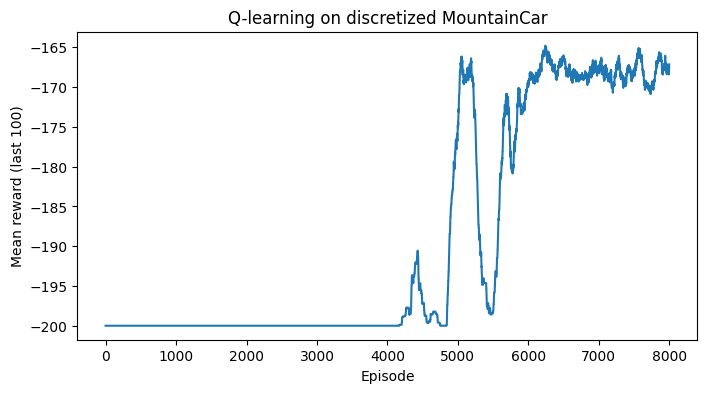

Initial state greedy action: right
Q(initial state): tensor([-10.0000, -10.0000,  -9.9988], dtype=torch.float64)


In [74]:
q_star_ql, greedy_actions_ql, rewards_ql = run_q_learning(
    episodes=8000,
    alpha=0.9,
    gamma=0.9,
    epsilon_start=1.0,
    render=False,
    seed=seed,
)

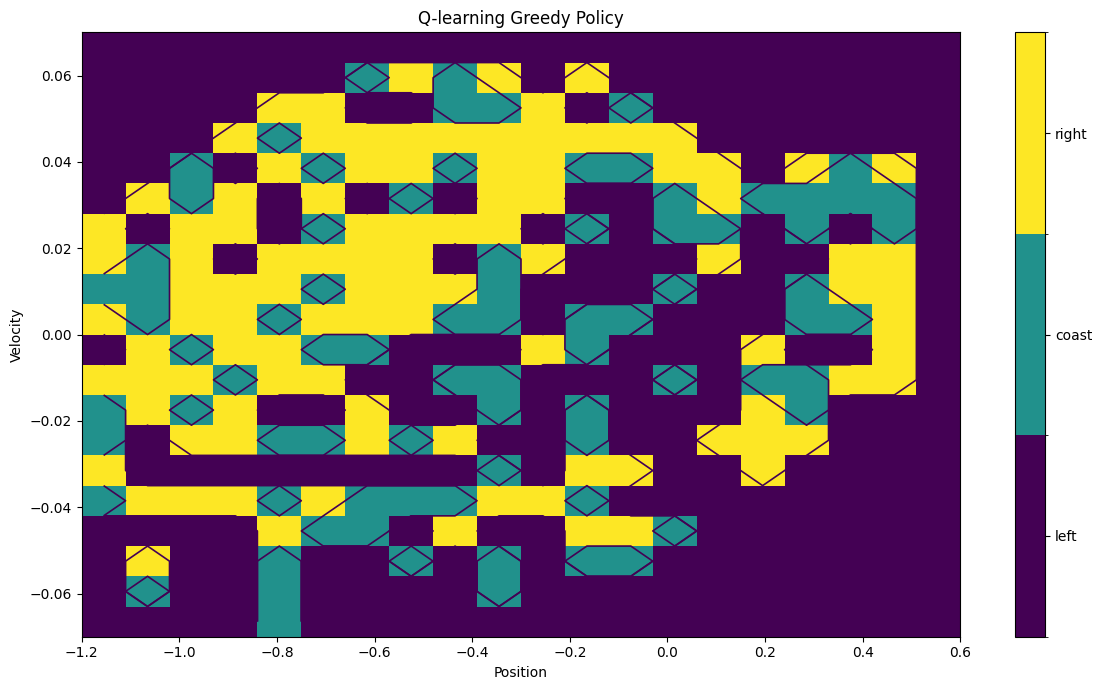

Starting simulation for mountain_car_optimal.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Success! Reached goal in 180 steps. Total Reward: -180.0
Saving GIF to mountain_car_optimal.gif...
Done!


In [75]:
# From learned Q-table -> greedy deterministic policy matrix
greedy_actions_ql = torch.argmax(q_star_ql, dim=1)

pi_matrix_ql = torch.zeros((N_STATES, N_ACTIONS), dtype=torch.float64)
pi_matrix_ql[torch.arange(N_STATES), greedy_actions_ql] = 1.0

# Optional: make goal state uniform instead of one-hot
pi_matrix_ql[GOAL_STATE_ID] = 1.0 / N_ACTIONS

plot_policy(
    pi_matrix_ql, N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title="Q-learning Greedy Policy"
)

evaluate_and_save_gif(pi_matrix_ql, "mountain_car_optimal.gif")

## Dataset Collection

Personalized dataset collection using the environment of gym, macro steps etc...

As we cant compute the occupancy as in grid, here we compute a trajectory of the optimal policy and that will be our occupancy.

In [15]:
def build_uniform_reset_distribution_from_policy_trajectory(
    policy_matrix,
    start_obs=INITIAL_OBS_REFERENCE,
    max_steps=TIME_LIMIT,
    seed=42,
):
    if hasattr(policy_matrix, "detach"):
        policy_matrix = policy_matrix.detach().cpu().numpy()
    else:
        policy_matrix = np.asarray(policy_matrix, dtype=np.float64)

    if policy_matrix.shape != (N_STATES, N_ACTIONS):
        raise ValueError(f"policy_matrix must have shape {(N_STATES, N_ACTIONS)}, got {policy_matrix.shape}")

    env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)
    obs, _ = env.reset(seed=seed)
    obs = np.asarray(start_obs, dtype=np.float64).copy()
    env.unwrapped.state = obs.copy()

    trajectory_state_ids = []
    i = 0
    for _ in range(max_steps):
        if is_goal_obs(obs):
            break

        s = obs_to_state_id(obs)
        trajectory_state_ids.append(s)

        action = int(np.argmax(policy_matrix[s]))
        obs, _, terminated, truncated, _ = env.step(action)

        if terminated or truncated:
            break
        i += 1

    env.close()

    unique_state_ids = list(dict.fromkeys(trajectory_state_ids))
    if len(unique_state_ids) == 0:
        raise ValueError("The trajectory from the initial state did not visit any non-terminal states.")

    uniform_prob = 1.0 / len(unique_state_ids)
    reset_distribution = {int(s): uniform_prob for s in unique_state_ids}

    return unique_state_ids, reset_distribution, i

Compute the dataset:

In [36]:
def collect_change_of_state_dataset_from_env_policy(
    policy_matrix,
    n_transitions=50_000,
    gamma=0.9,
    epsilon=0.2,
    proportions=(0.7, 0.3),
    episode_based=True,
    max_steps_per_episode=500,
    reset_probs=None,
    custom_reset_distribution=None,
    reset_obs_mode="uniform_in_bin",
    seed=42,
    save_path=None,
    verbose=True,
    max_repeat_same_state=10_000,
    drop_self_transitions=False,
    add_goal_self_loops=True,
    goal_self_loops_per_hit=1,
    goal_self_loop_reward=0.0,
    goal_self_loop_action="sample",   # "sample" or int in [0, N_ACTIONS-1]
):
    rng = np.random.default_rng(seed)
    env = gym.make(ENV_ID, goal_velocity=GOAL_VELOCITY)

    if reset_probs is None:
        reset_probs = {"x0": 0.5, "random": 0.5}

    if hasattr(policy_matrix, "detach"):
        policy_matrix = policy_matrix.detach().cpu().numpy()
    else:
        policy_matrix = np.asarray(policy_matrix, dtype=np.float64)

    if policy_matrix.shape != (N_STATES, N_ACTIONS):
        raise ValueError(f"policy_matrix must have shape {(N_STATES, N_ACTIONS)}, got {policy_matrix.shape}")

    row_sums = policy_matrix.sum(axis=1, keepdims=True)
    bad_rows = np.isclose(row_sums, 0.0).squeeze()
    if np.any(bad_rows):
        policy_matrix = policy_matrix.copy()
        policy_matrix[bad_rows] = 1.0 / N_ACTIONS
        row_sums = policy_matrix.sum(axis=1, keepdims=True)
    policy_matrix = policy_matrix / row_sums

    p_policy, p_random = proportions
    if not np.isclose(p_policy + p_random, 1.0):
        raise ValueError("proportions must sum to 1.0")

    reset_mode_names = list(reset_probs.keys())
    reset_mode_probs = np.array(list(reset_probs.values()), dtype=np.float64)
    if np.any(reset_mode_probs < 0):
        raise ValueError("reset_probs must be nonnegative")
    if np.isclose(reset_mode_probs.sum(), 0.0):
        raise ValueError("reset_probs must have positive total mass")
    reset_mode_probs = reset_mode_probs / reset_mode_probs.sum()

    if "custom" in reset_mode_names:
        if custom_reset_distribution is None:
            raise ValueError("custom_reset_distribution must be provided when reset_probs includes 'custom'.")
        if not isinstance(custom_reset_distribution, dict):
            raise TypeError("custom_reset_distribution must be a dict mapping state_id -> probability.")

        custom_state_ids = np.array(list(custom_reset_distribution.keys()), dtype=np.int64)
        custom_state_probs = np.array(list(custom_reset_distribution.values()), dtype=np.float64)

        if len(custom_state_ids) == 0:
            raise ValueError("custom_reset_distribution cannot be empty.")
        if np.any(custom_state_ids < 0) or np.any(custom_state_ids >= CORE_STATE_COUNT):
            raise ValueError(f"custom reset state ids must be in [0, {CORE_STATE_COUNT - 1}].")
        if np.any(custom_state_probs < 0):
            raise ValueError("custom reset probabilities must be nonnegative.")
        if np.isclose(custom_state_probs.sum(), 0.0):
            raise ValueError("custom_reset_distribution must have positive total mass.")

        custom_state_probs = custom_state_probs / custom_state_probs.sum()
    else:
        custom_state_ids = None
        custom_state_probs = None

    def sample_obs_from_state_id(state_id, mode="uniform_in_bin"):
        state_id = int(state_id)
        if state_id == GOAL_STATE_ID:
            raise ValueError("Cannot reset directly into GOAL_STATE_ID")

        if mode == "center":
            return state_id_to_center_obs(state_id).copy()

        if mode == "uniform_in_bin":
            multi_bin = state_id_to_multi_bin(state_id)
            obs = np.empty(len(multi_bin), dtype=np.float64)
            for d, idx in enumerate(multi_bin):
                lo = BIN_EDGES[d][idx]
                hi = BIN_EDGES[d][idx + 1]
                obs[d] = rng.uniform(lo, hi)

            obs = clip_obs(obs)

            for _ in range(10):
                if (not is_goal_obs(obs)) and (obs_to_state_id(obs) == state_id):
                    return obs
                for d, idx in enumerate(multi_bin):
                    lo = BIN_EDGES[d][idx]
                    hi = BIN_EDGES[d][idx + 1]
                    obs[d] = rng.uniform(lo, hi)
                obs = clip_obs(obs)

            return state_id_to_center_obs(state_id).copy()

        raise ValueError(f"Unknown reset_obs_mode: {mode}")

    def reset_env():
        mode = rng.choice(reset_mode_names, p=reset_mode_probs)

        obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))

        if mode == "x0":
            obs = INITIAL_OBS_REFERENCE.copy()
            env.unwrapped.state = obs.copy()
            return obs, mode

        if mode == "random":
            while is_goal_obs(obs):
                obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
            return obs, mode

        if mode == "custom":
            sampled_idx = int(rng.choice(len(custom_state_ids), p=custom_state_probs))
            sampled_state = int(custom_state_ids[sampled_idx])
            obs = sample_obs_from_state_id(sampled_state, mode=reset_obs_mode)
            env.unwrapped.state = obs.copy()
            return obs, mode

        raise ValueError(f"Unknown reset mode: {mode}")

    def choose_policy_id():
        return int(rng.choice([0, 1], p=[p_policy, p_random]))

    def choose_action(obs, policy_id):
        s = obs_to_state_id(obs)

        if policy_id == 1:
            return int(rng.integers(N_ACTIONS))

        if rng.random() < epsilon:
            return int(rng.integers(N_ACTIONS))

        return int(rng.choice(N_ACTIONS, p=policy_matrix[s]))

    def choose_goal_loop_action():
        if goal_self_loop_action == "sample":
            return int(rng.integers(N_ACTIONS))
        return int(goal_self_loop_action)

    data = {
        "episode": [],
        "step": [],
        "state": [],
        "action": [],
        "reward": [],
        "next_state": [],
        "policy_id": [],
        "reset_mode": [],
    }

    episode = 0
    step_in_episode = 0
    obs, reset_mode = reset_env()
    current_policy_id = choose_policy_id() if episode_based else None

    def append_row(ep, st, s, a, r, ns, pid, rmode):
        data["episode"].append(ep)
        data["step"].append(st)
        data["state"].append(s)
        data["action"].append(a)
        data["reward"].append(r)
        data["next_state"].append(ns)
        data["policy_id"].append(pid)
        data["reset_mode"].append(rmode)

    with tqdm(total=n_transitions, desc="Collecting dataset") as pbar:
        while len(data["state"]) < n_transitions:
            s = obs_to_state_id(obs)
            policy_id = current_policy_id if episode_based else choose_policy_id()
            action = choose_action(obs, policy_id)

            accumulated_reward = 0.0
            terminated = False
            truncated = False
            next_obs = obs
            primitive_steps = 0

            while True:
                next_obs, reward, term, trunc, _ = env.step(action)
                accumulated_reward += (gamma ** primitive_steps) * float(reward)

                primitive_steps += 1
                step_in_episode += 1

                terminated = terminated or term
                truncated = truncated or trunc

                if terminated:
                    next_s = GOAL_STATE_ID
                    break

                next_s = obs_to_state_id(next_obs)

                if next_s != s:
                    break

                if truncated or step_in_episode >= max_steps_per_episode:
                    break

                if primitive_steps >= max_repeat_same_state:
                    break

            keep_row = (next_s != s) or terminated or (not drop_self_transitions)

            if keep_row and len(data["state"]) < n_transitions:
                append_row(episode, step_in_episode, s, action, -1 * accumulated_reward, next_s, policy_id, reset_mode)
                pbar.update(1)

            if terminated and add_goal_self_loops:
                for _ in range(goal_self_loops_per_hit):
                    if len(data["state"]) >= n_transitions:
                        break
                    append_row(
                        episode,
                        step_in_episode,
                        GOAL_STATE_ID,
                        choose_goal_loop_action(),
                        goal_self_loop_reward,
                        GOAL_STATE_ID,
                        policy_id,
                        reset_mode,
                    )
                    pbar.update(1)

            obs = next_obs

            if terminated or truncated or step_in_episode >= max_steps_per_episode:
                episode += 1
                step_in_episode = 0
                obs, reset_mode = reset_env()
                if episode_based:
                    current_policy_id = choose_policy_id()

    env.close()

    df = pd.DataFrame(data)

    if verbose:
        counts = df["policy_id"].value_counts(normalize=True).sort_index()
        reset_counts = df["reset_mode"].value_counts(normalize=True)
        print(f"Collected {len(df)} change-of-state transitions over {df['episode'].nunique()} episodes")
        print(f"Policy 0 (policy + epsilon exploration): {counts.get(0, 0.0):.3f}")
        print(f"Policy 1 (random):                       {counts.get(1, 0.0):.3f}")
        print("Reset mode frequencies:")
        print(reset_counts.sort_index())

    df_fogas = df[["state", "action", "reward", "next_state"]]

    if save_path is not None:
        df_fogas.to_csv(save_path, index=False)
        if verbose:
            print(f"Saved dataset to {save_path}")

    return df_fogas

In [44]:
trajectory_state_ids, trajectory_reset_distribution, _ = build_uniform_reset_distribution_from_policy_trajectory(
    policy_matrix=pi_matrix_ql,
    start_obs=INITIAL_OBS_REFERENCE,
    max_steps=TIME_LIMIT,
    seed=42,
)

df = collect_change_of_state_dataset_from_env_policy(
    policy_matrix=pi_matrix_ql,
    n_transitions=50_000,
    epsilon=0.4,
    proportions=(0.8, 0.2),
    episode_based=True,
    max_steps_per_episode=200,
    reset_probs={"x0": 0.1, "custom": 0.9},
    custom_reset_distribution=trajectory_reset_distribution,
    reset_obs_mode="uniform_in_bin",
    seed=42,
    save_path=DATASET_PATH,
    verbose=True,
    drop_self_transitions=False,   # set True if you want only true state-change rows
)

Collected 50000 change-of-state transitions over 754 episodes
Policy 0 (policy + epsilon exploration): 0.815
Policy 1 (random):                       0.185
Reset mode frequencies:
reset_mode
custom    0.9121
x0        0.0879
Name: proportion, dtype: float64
Saved dataset to /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar.csv


Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/datasets/mountaincar.csv
Total transitions: 50,000
Unique (state, action) pairs: 810
Unique states visited: 278
Unique actions taken: 3
--------------------------------------------------
Pair Frequency Statistics:
  Min count:    1
  Max count:    363
  Mean count:   61.73
  Std count:    65.27
  Median count: 40.0
--------------------------------------------------
Coverage Statistics:
  Total possible pairs: 1,203
  Coverage: 67.33%
  Missing pairs: 393

Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         50000
  MDP dims (N, A, d):        (401, 3, 1203)
  gamma:                    0.59049
  beta (ridge):             0.001
  policy source:            mdp.pi_star

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 1

  Feature occupancy λ_pi summary:
    ||λ||_2:                1
    ||λ||_1:                1
    max |λ_i|:              1

  Emp

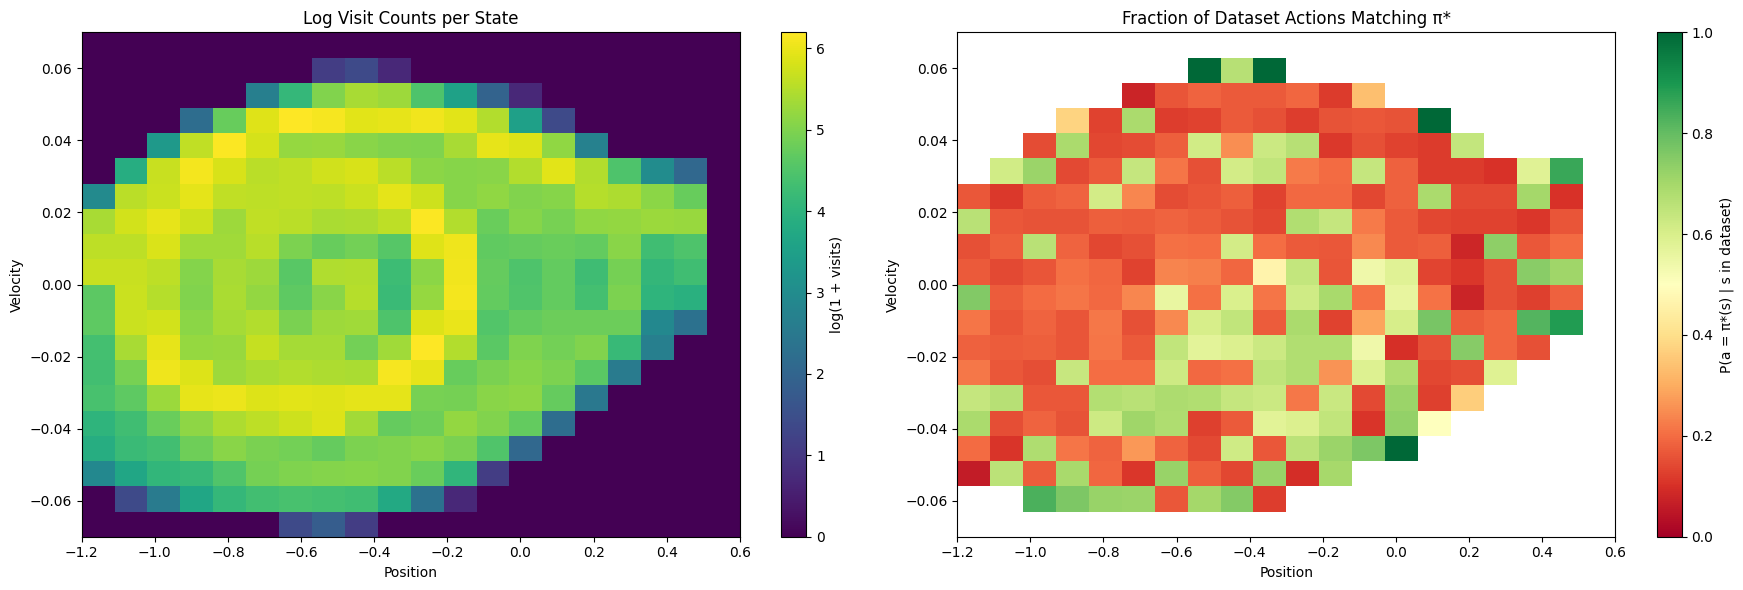

In [76]:
# ── 2. Build the analyzer ────────────────────────────────────────────────────
analyzer = DatasetAnalyzer(DATASET_PATH)

# ── 3. Global summary ────────────────────────────────────────────────────────
analyzer.summary(n_states=N_STATES, n_actions=N_ACTIONS)

# ── 4. Feature coverage ratio w.r.t. optimal policy (the key FOGAS metric) ──
ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-3,
    use_optimal_policy=True,   # uses mdp.pi_star
    verbose=True,
    return_details=False,
)
print(f"\nCoverage ratio: {ratio:.4f}")

# ── 5. State coverage in phase space ─────────────────────────────────────────
CORE_STATE_COUNT = int(np.prod(STATE_BINS))

visited_states = set(df["state"].unique())
all_states     = set(range(CORE_STATE_COUNT))
unvisited      = all_states - visited_states

print(f"\nState coverage:  {len(visited_states)}/{CORE_STATE_COUNT}  "
      f"({100*len(visited_states)/CORE_STATE_COUNT:.1f}%)")
print(f"Unvisited states: {len(unvisited)}")

# ── 6. Visited / unvisited map in phase space ─────────────────────────────────
visit_count_grid  = np.zeros(tuple(STATE_BINS), dtype=np.int64)
optimal_match_grid = np.full(tuple(STATE_BINS), fill_value=np.nan)

greedy_actions = torch.argmax(mdp.pi_star.reshape(N_STATES, N_ACTIONS), dim=1).cpu().numpy()

for s in all_states:
    i, j          = state_id_to_multi_bin(s)
    visit_count_grid[i, j] = analyzer.count_state(s)

for s in visited_states:
    if s >= CORE_STATE_COUNT:
        continue
    i, j = state_id_to_multi_bin(s)
    # fraction of visits in state s where dataset action == optimal action
    total = analyzer.count_state(s)
    on_policy = analyzer.count_pair(s, int(greedy_actions[s]))
    optimal_match_grid[i, j] = on_policy / total if total > 0 else np.nan

# Plot 1 — visit counts (log scale)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

im0 = axes[0].pcolormesh(
    BIN_EDGES[0], BIN_EDGES[1],
    np.log1p(visit_count_grid).T,
    cmap="viridis", shading="flat",
)
axes[0].set_title("Log Visit Counts per State")
axes[0].set_xlabel("Position"); axes[0].set_ylabel("Velocity")
fig.colorbar(im0, ax=axes[0], label="log(1 + visits)")

# Plot 2 — fraction of optimal action taken per visited state
im1 = axes[1].pcolormesh(
    BIN_EDGES[0], BIN_EDGES[1],
    optimal_match_grid.T,
    cmap="RdYlGn", shading="flat", vmin=0, vmax=1,
)
axes[1].set_title("Fraction of Dataset Actions Matching π*")
axes[1].set_xlabel("Position"); axes[1].set_ylabel("Velocity")
fig.colorbar(im1, ax=axes[1], label="P(a = π*(s) | s in dataset)")

plt.tight_layout()
plt.show()


In [77]:
# 1. Initialize the Vectorized Solver
# Note: Ensure mdp is already defined (as seen in cell 13 of your notebook)
solver = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=DATASET_PATH,
    device=device,
    beta=1e-6,
    seed=seed
)

# 2. Initialize the Evaluator
evaluator = FOGASEvaluator(solver)

# 3. Initialize the Optimizer using "reward" as the metric
# 'reward' in FOGASEvaluator returns the negative expected return (minimization)
optimizer = FOGASHyperOptimizer(
    solver=solver,
    metric_callable=evaluator.get_metric("reward"), 
    seed=seed
)

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-06, n=50000)


In [78]:
# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.0001, 
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=20000
)

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:38<00:00, 202.88it/s]


tensor([[0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        [0.3294, 0.3400, 0.3306],
        ...,
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3334, 0.3333]], device='cuda:0', dtype=torch.float64)

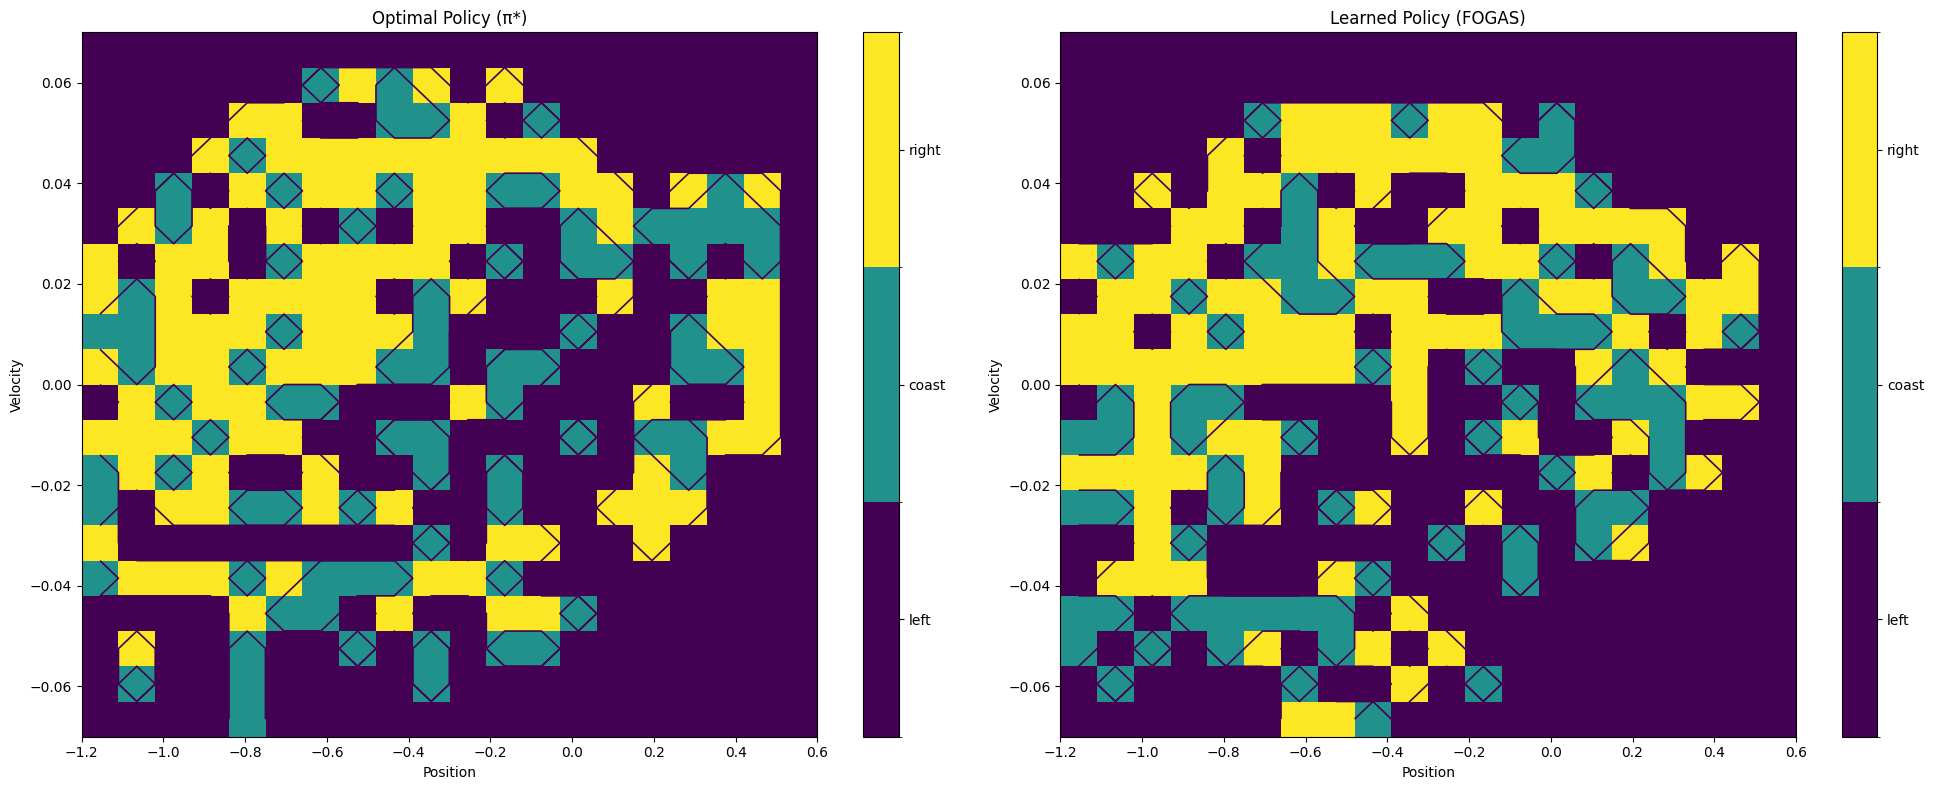

In [79]:
pi_solver = torch.as_tensor(solver.pi, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()
pi_ql = torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()

# 1. Create a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 2. Plot the Optimal Policy on the first axis
plot_policy(
    pi_ql, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title="Optimal Policy (π*)",
    ax=axes[0]
)

plot_policy(
    pi_solver, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title=f"Learned Policy (FOGAS)",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [80]:
print_policy_rows(solver.pi, pi_ql)


Policy rows
Legend: [L, C, R] = [left, coast, right]
Format: main policy | compare policy

s=  0  pos= -1.155  vel= -0.067  pi=[0.333, 0.333, 0.333]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  1  pos= -1.155  vel= -0.060  pi=[0.333, 0.333, 0.333]  argmax=left   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> same
s=  2  pos= -1.155  vel= -0.053  pi=[0.329, 0.340, 0.331]  argmax=coast   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> DIFF
s=  3  pos= -1.155  vel= -0.045  pi=[0.328, 0.347, 0.325]  argmax=coast   |   cmp=[1.000, 0.000, 0.000]  argmax=left  -> DIFF
s=  4  pos= -1.155  vel= -0.039  pi=[0.354, 0.320, 0.326]  argmax=left   |   cmp=[0.000, 1.000, 0.000]  argmax=coast  -> DIFF
s=  5  pos= -1.155  vel= -0.032  pi=[0.365, 0.318, 0.317]  argmax=left   |   cmp=[0.000, 0.000, 1.000]  argmax=right  -> DIFF
s=  6  pos= -1.155  vel= -0.024  pi=[0.323, 0.363, 0.314]  argmax=coast   |   cmp=[0.000, 1.000, 0.000]  argmax=coast  -> same
s=  7  pos= -1.155  vel= -0

In [81]:
# Evaluate Random/Heuristic Policy
print("Evaluating Random Policy...")
run_1 = evaluate_policy_mean_steps(torch.zeros((N_STATES, N_ACTIONS)), n_trials=10)

# Evaluate Solver Policy
print("Evaluating Solver Policy...")
run_2 = evaluate_policy_mean_steps(solver.pi, n_trials=10)

print(f"Improvement: {run_1 - run_2} fewer steps!")

Evaluating Random Policy...
Evaluation over 10 trials: Mean Steps = 200.00 (0/10 reached goal)
Evaluating Solver Policy...
Evaluation over 10 trials: Mean Steps = 163.70 (10/10 reached goal)
Improvement: 36.30000000000001 fewer steps!


In [300]:
# 1. Run the solver with your specific parameters
solver.run(
    alpha=0.001, 
    eta=0.00002, 
    rho=0.5, 
    tqdm_print=True, 
    T=20000
)

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [01:39<00:00, 201.66it/s]


tensor([[3.3333e-01, 3.3333e-01, 3.3333e-01],
        [3.9231e-01, 2.5667e-01, 3.5102e-01],
        [3.4311e-01, 3.7771e-01, 2.7919e-01],
        ...,
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [3.3333e-01, 3.3333e-01, 3.3333e-01],
        [9.9957e-01, 2.3285e-04, 1.9395e-04]], device='cuda:0',
       dtype=torch.float64)

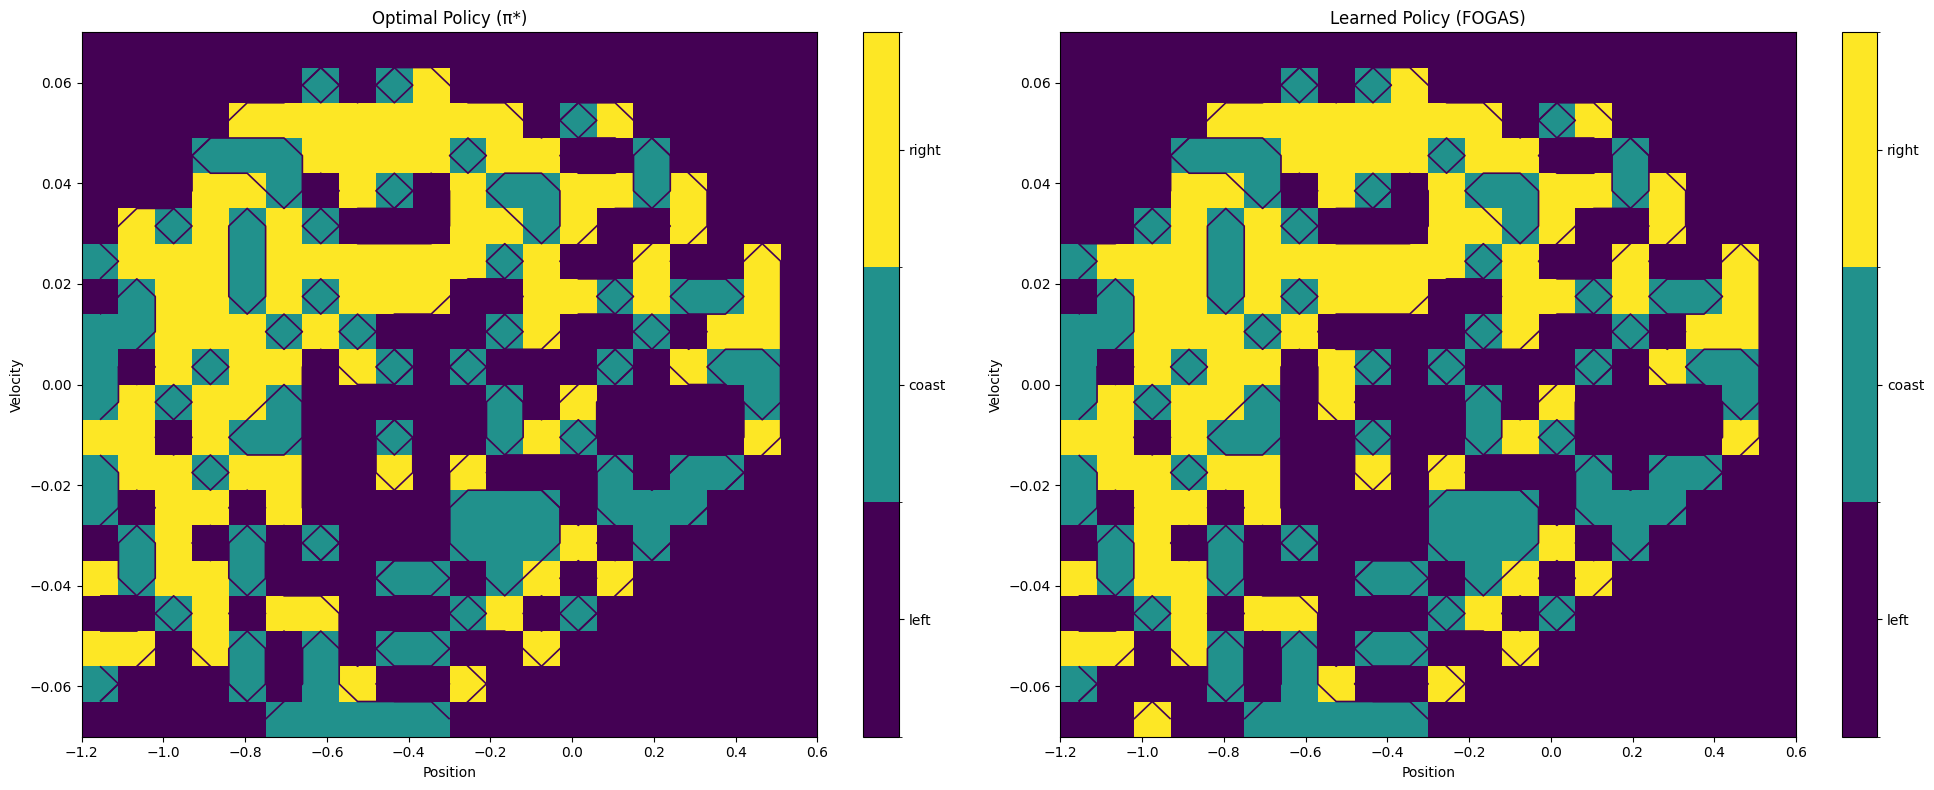

In [301]:
pi_solver = torch.as_tensor(solver.pi, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()
pi_ql = torch.as_tensor(pi_matrix_ql, dtype=torch.float64).reshape(N_STATES, N_ACTIONS).detach().cpu()

solver_argmax = torch.argmax(pi_solver, dim=1)
solver_argmin = torch.argmin(pi_solver, dim=1)   # leftmost if tie
ql_argmax = torch.argmax(pi_ql, dim=1)

diff_mask = solver_argmax != ql_argmax
diff_mask[GOAL_STATE_ID] = False   # optional

pi_solver_greedy = pi_solver.clone()
pi_solver_greedy[diff_mask] = 0.0
diff_states = torch.where(diff_mask)[0]
pi_solver_greedy[diff_states, solver_argmin[diff_states]] = 1.0

# 1. Create a side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 2. Plot the Optimal Policy on the first axis
plot_policy(
    pi_matrix_ql, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title="Optimal Policy (π*)",
    ax=axes[0]
)

plot_policy(
    pi_solver_greedy, 
    N_STATES, N_ACTIONS, STATE_BINS, BIN_CENTERS, BIN_EDGES,
    state_id_to_multi_bin,
    CORE_STATE_COUNT=int(np.prod(STATE_BINS)),
    title=f"Learned Policy (FOGAS)",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In [302]:
evaluate_and_save_gif(pi_solver_greedy, "mountain_car_fogas.gif")

Starting simulation for mountain_car_fogas.gif...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Success! Reached goal in 186 steps. Total Reward: -186.0
Saving GIF to mountain_car_fogas.gif...
Done!


In [304]:
# Evaluate Random/Heuristic Policy
print("Evaluating Random Policy...")
run_1 = evaluate_policy_mean_steps(torch.zeros((N_STATES, N_ACTIONS)), n_trials=10)

# Evaluate Solver Policy
print("Evaluating Solver Policy...")
run_2 = evaluate_policy_mean_steps(pi_solver_greedy, n_trials=10)

print(f"Improvement: {run_1 - run_2} fewer steps!")

Evaluating Random Policy...
Evaluation over 10 trials: Mean Steps = 200.00 (0/10 reached goal)
Evaluating Solver Policy...
Evaluation over 10 trials: Mean Steps = 179.60 (9/10 reached goal)
Improvement: 20.400000000000006 fewer steps!
